# Umineko Accelerometer Data — Statistics Analysis

**Dataset**: Black-tailed gull (umineko) behavior classification  
**Data source**: `data/umineko/raw/umineko_{year}.npy` (2018, 2019, 2022)  
**Windowed cache**: `data/umineko/data.npy` / `data/umineko/label.npy`

**Label names** (canonical grouping):
| ID | Behavior |
|----|----------|
| 0  | ground_stat (ground_stationary / stationary / preening) |
| 1  | ground_active |
| 2  | bathing |
| 3  | flying_active |
| 4  | flying_passive |
| 5  | foraging |
| 6  | body_shaking |

## 0. Imports & Configuration

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import kruskal
from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.titlesize': 13, 'axes.labelsize': 11})
sns.set_palette('tab10')

NOTEBOOK_DIR = os.path.abspath('')
DATA_DIR     = os.path.join(NOTEBOOK_DIR, '..', '..', 'data', 'umineko')
NPY_DATA     = os.path.join(DATA_DIR, 'data.npy')
NPY_LABEL    = os.path.join(DATA_DIR, 'label.npy')
FIG_DIR      = os.path.join(NOTEBOOK_DIR, 'figures')
os.makedirs(FIG_DIR, exist_ok=True)

# Map raw string labels to canonical integer label IDs
LABEL_STR_TO_ID = {
    'ground_stationary': 0, 'stationary': 0, 'preening': 0,
    'ground_active': 1,
    'bathing': 2, 'bathing_poss': 2,
    'flying_active': 3,
    'flying_passive': 4,
    'poss_foraging': 5, 'foraging': 5, 'foraging_non-fish': 5,
    'foraging_insect_poss': 5, 'forgaing_insect': 5, 'foraging_poss': 5,
    'foraging_steal': 5, 'foraging_fish_poss': 5,
    'body_shaking': 6,
}

LABEL_NAMES = {
    0: 'ground_stat', 1: 'ground_active', 2: 'bathing',
    3: 'flying_active', 4: 'flying_passive', 5: 'foraging', 6: 'body_shaking',
}

AXES        = ['acc_x', 'acc_y', 'acc_z']
COLORS      = plt.cm.tab10(np.linspace(0, 1, 10))
SAMPLE_RATE = 25
WINDOW_SIZE = 50
YEARS       = [2018, 2019, 2022]

print('npy  :', NPY_DATA)
print('figs :', FIG_DIR)

npy  : /Users/cassie/Documents/code/DeepView/analysis/umineko/../../data/umineko/data.npy
figs : /Users/cassie/Documents/code/DeepView/analysis/umineko/figures


## 1. Preprocessing: Raw npy → Windowed npy

In [2]:
def sliding_window(data_np, len_sw, step):
    windows = []
    for idx in range(0, data_np.shape[0] - len_sw - step, step):
        windows.append(data_np[idx: idx + len_sw, :])
    windows.append(data_np[-1 - len_sw: -1, :])
    return np.stack(windows, axis=0)


def build_windowed_npy(data_dir, npy_data_path, npy_label_path, len_sw=50, step=50):
    dfs = []
    for yr in YEARS:
        path = os.path.join(data_dir, 'raw', f'umineko_{yr}.npy')
        if not os.path.exists(path):
            print(f'  Missing: {path}')
            continue
        d  = np.load(path, allow_pickle=True).item()
        ld = d['labeled_data'].copy()
        ld['year'] = yr
        dfs.append(ld)
    df = pd.concat(dfs, ignore_index=True)
    print(f'Total labeled rows: {len(df):,}')

    # Map string label to canonical ID; drop unknown (-2 or unmapped)
    df['canon_id'] = df['label'].map(LABEL_STR_TO_ID)
    df = df[df['canon_id'].notna()].copy()
    df['canon_id'] = df['canon_id'].astype(int)
    print(f'After mapping to known classes: {len(df):,}')

    acc = df[AXES].values.astype(float)
    mean_v = acc.mean(axis=0)
    std_v  = np.maximum(acc.std(axis=0), 1e-5)
    df[AXES] = (acc - mean_v) / std_v

    selected_np = df[AXES + ['canon_id']].values
    print('Applying sliding window ...')
    windows = sliding_window(selected_np, len_sw, step)

    data_b  = np.transpose(windows[:, :, :3], (0, 2, 1))
    label_b = windows[:, :, 3]

    np.save(npy_data_path, data_b)
    np.save(npy_label_path, label_b)
    print(f'Saved data.npy  : {data_b.shape}')
    print(f'Saved label.npy : {label_b.shape}')
    return data_b, label_b


if os.path.exists(NPY_DATA) and os.path.exists(NPY_LABEL):
    print('Loading cached npy ...')
    X = np.load(NPY_DATA)
    Y = np.load(NPY_LABEL)
else:
    X, Y = build_windowed_npy(DATA_DIR, NPY_DATA, NPY_LABEL)

y = Y[:, 0].astype(int)
labels_to_analyze = sorted(np.unique(y))
class_names       = [LABEL_NAMES.get(l, str(l)) for l in labels_to_analyze]

print(f'X shape       : {X.shape}')
print(f'Unique labels : {labels_to_analyze}')
print(f'Label counts  : {dict(sorted(Counter(y).items()))}')

Total labeled rows: 1,098,025
After mapping to known classes: 919,691
Applying sliding window ...
Saved data.npy  : (18393, 3, 50)
Saved label.npy : (18393, 50)
X shape       : (18393, 3, 50)
Unique labels : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
Label counts  : {np.int64(0): 5307, np.int64(1): 107, np.int64(2): 753, np.int64(3): 10348, np.int64(4): 1706, np.int64(5): 163, np.int64(6): 9}


## 2. Load Raw Data for Global Statistics

In [3]:
dfs_raw = []
for yr in YEARS:
    path = os.path.join(DATA_DIR, 'raw', f'umineko_{yr}.npy')
    if not os.path.exists(path): continue
    d = np.load(path, allow_pickle=True).item()
    ld = d['labeled_data'].copy()
    ld['year'] = yr
    ld['canon_id'] = ld['label'].map(LABEL_STR_TO_ID)
    dfs_raw.append(ld)
df_all    = pd.concat(dfs_raw, ignore_index=True)
df_known  = df_all[df_all['canon_id'].notna()].copy()
df_known['canon_id'] = df_known['canon_id'].astype(int)
print(f'Total labeled rows: {len(df_all):,}')
print(f'Rows with known class: {len(df_known):,}')
print(df_known[['label','canon_id']].drop_duplicates().sort_values('canon_id').to_string(index=False))

Total labeled rows: 1,098,025
Rows with known class: 919,691
               label  canon_id
   ground_stationary         0
            preening         0
          stationary         0
       ground_active         1
        bathing_poss         2
             bathing         2
       flying_active         3
      flying_passive         4
foraging_insect_poss         5
  foraging_fish_poss         5
       foraging_poss         5
     forgaing_insect         5
       poss_foraging         5
   foraging_non-fish         5
            foraging         5
      foraging_steal         5
        body_shaking         6


## 3. Class Distribution

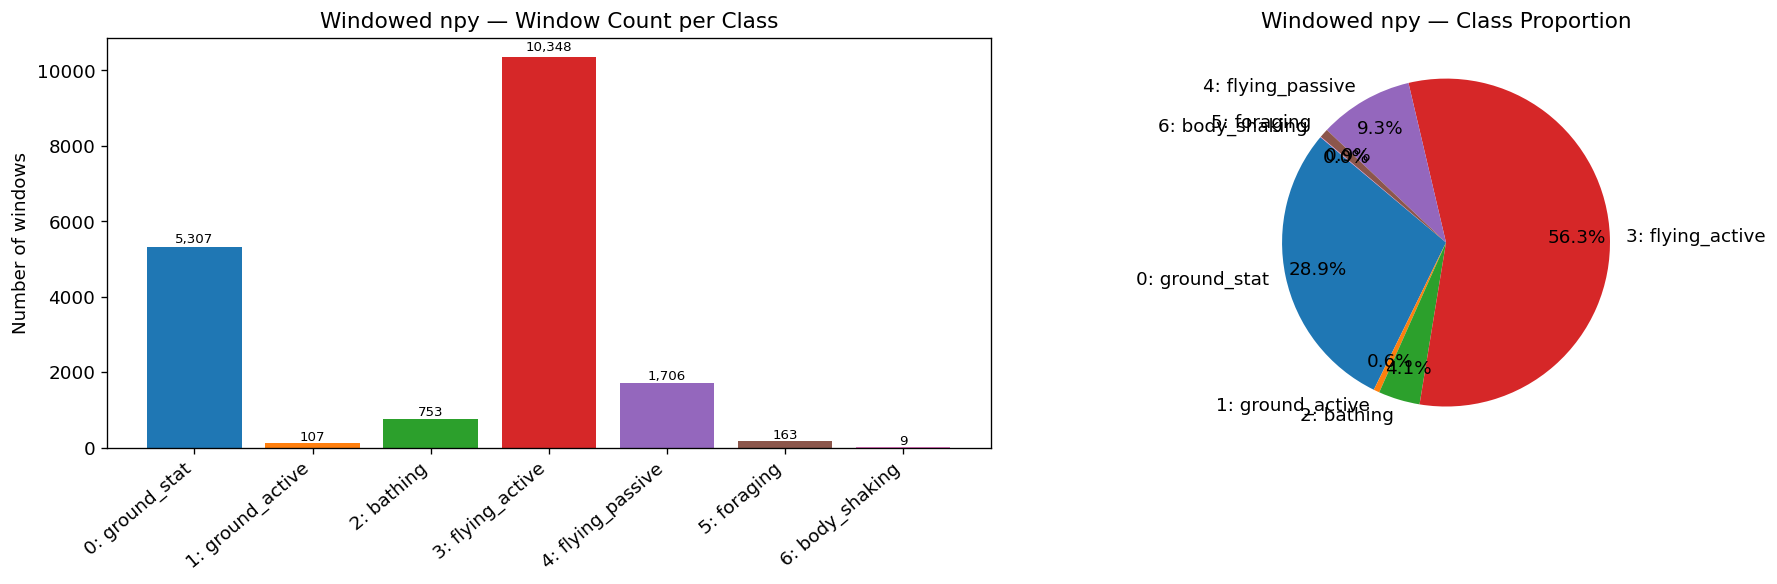

In [4]:
cnt    = Counter(y)
counts = [cnt.get(l, 0) for l in labels_to_analyze]
props  = np.array(counts) / sum(counts) * 100
names  = [f"{l}: {LABEL_NAMES.get(l,'?')}" for l in labels_to_analyze]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
ax = axes[0]
bars = ax.bar(range(len(labels_to_analyze)), counts, color=COLORS[:len(labels_to_analyze)])
ax.set_xticks(range(len(labels_to_analyze)))
ax.set_xticklabels(names, rotation=40, ha='right')
ax.set_title('Windowed npy — Window Count per Class')
ax.set_ylabel('Number of windows')
for bar, v in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01,
            f'{v:,}', ha='center', va='bottom', fontsize=8)

ax = axes[1]
ax.pie(props, labels=names, autopct='%1.1f%%', colors=COLORS[:len(labels_to_analyze)],
       startangle=140, pctdistance=0.8)
ax.set_title('Windowed npy — Class Proportion')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'class_dist_npy.png'), bbox_inches='tight')
plt.show()

In [5]:
p           = np.array(counts) / sum(counts)
entropy     = -np.sum(p * np.log2(p + 1e-12))
max_entropy = np.log2(len(p))
gini        = 1 - np.sum(p**2)
ir          = max(p) / min(p)

print('=== Class Imbalance Metrics ===')
print(f'  Classes          : {len(p)}')
print(f'  Shannon entropy  : {entropy:.4f}  (max = {max_entropy:.4f})')
print(f'  Normalized entropy: {entropy/max_entropy:.4f}')
print(f'  Gini impurity    : {gini:.4f}')
print(f'  Imbalance ratio  : {ir:.1f}x')
for label_id, pi in zip(labels_to_analyze, p):
    w = (1/pi) / np.sum(1/p)
    print(f'  {label_id} {LABEL_NAMES.get(label_id,"?"):<20} p={pi:.4f}  weight={w:.4f}')

=== Class Imbalance Metrics ===
  Classes          : 7
  Shannon entropy  : 1.6002  (max = 2.8074)
  Normalized entropy: 0.5700
  Gini impurity    : 0.5898
  Imbalance ratio  : 1149.8x
  0 ground_stat          p=0.2885  weight=0.0015
  1 ground_active        p=0.0058  weight=0.0726
  2 bathing              p=0.0409  weight=0.0103
  3 flying_active        p=0.5626  weight=0.0008
  4 flying_passive       p=0.0928  weight=0.0046
  5 foraging             p=0.0089  weight=0.0476
  6 body_shaking         p=0.0005  weight=0.8627


## 4. Per-Year & Per-Individual Analysis

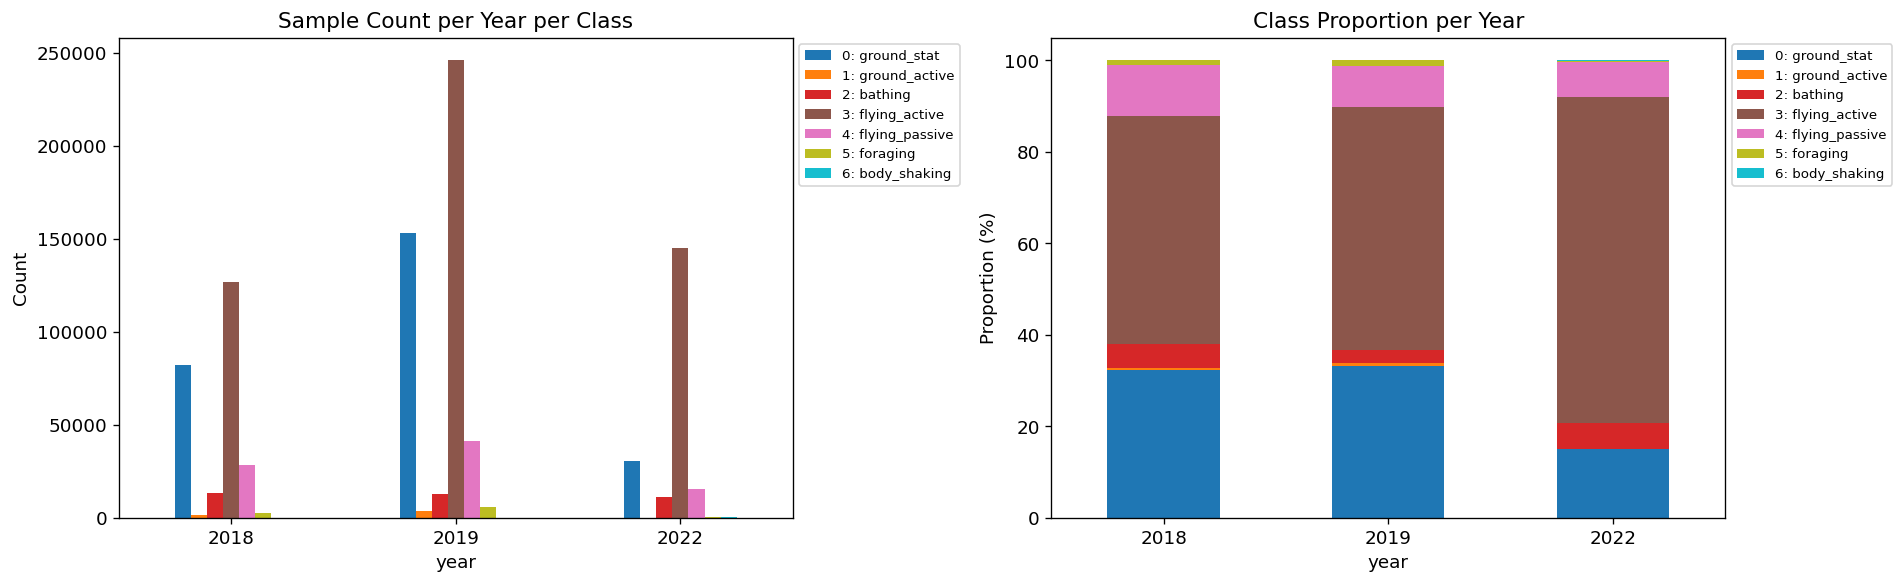

In [6]:
year_label = df_known.groupby(['year', 'canon_id']).size().unstack(fill_value=0)
year_label.columns = [f"{int(c)}: {LABEL_NAMES.get(int(c),'?')}" for c in year_label.columns]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
ax = axes[0]
year_label.plot(kind='bar', ax=ax, colormap='tab10', stacked=False)
ax.set_title('Sample Count per Year per Class')
ax.set_xticklabels(year_label.index, rotation=0)
ax.set_ylabel('Count')
ax.legend(loc='upper left', bbox_to_anchor=(1,1), fontsize=8)

ax = axes[1]
year_norm = year_label.div(year_label.sum(axis=1), axis=0) * 100
year_norm.plot(kind='bar', stacked=True, ax=ax, colormap='tab10')
ax.set_title('Class Proportion per Year')
ax.set_xticklabels(year_label.index, rotation=0)
ax.set_ylabel('Proportion (%)')
ax.legend(loc='upper left', bbox_to_anchor=(1,1), fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'class_dist_per_year.png'), bbox_inches='tight')
plt.show()

Individuals (n=26): ['2019LB01', '2019LB02', '2019LB03', '2019LB04', '2019LB05', '2019LB06', '2019LB07', '2019LB08', '2019LB09', '2019LB10', '2019LB11', '2019LB12', '2019LB13', '2019LB14', 'LB02', 'LB03', 'LB07', 'LB08', 'LB09', 'LB10', 'LB12', 'LB13', 'LB14', 'LB15', 'LB16', 'LB17']


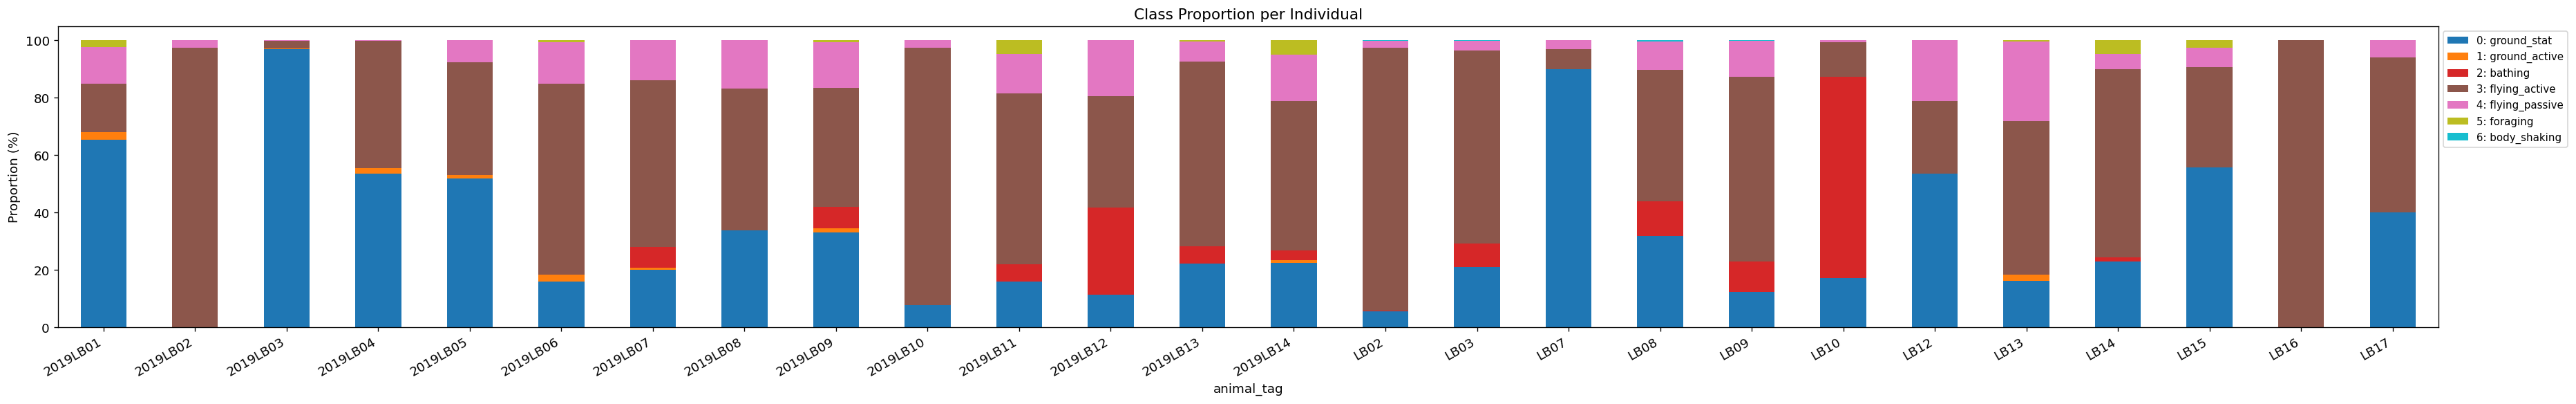

In [7]:
individuals = sorted(df_known['animal_tag'].dropna().unique())
print(f'Individuals (n={len(individuals)}): {list(individuals)}')

pivot_ind = df_known.groupby(['animal_tag','canon_id']).size().unstack(fill_value=0)
pivot_ind.columns = [f"{int(c)}: {LABEL_NAMES.get(int(c),'?')}" for c in pivot_ind.columns]

fig, ax = plt.subplots(figsize=(max(14, len(individuals)*1.2), 5))
pivot_norm = pivot_ind.div(pivot_ind.sum(axis=1), axis=0) * 100
pivot_norm.plot(kind='bar', stacked=True, ax=ax, colormap='tab10')
ax.set_title('Class Proportion per Individual')
ax.set_xticklabels(pivot_ind.index, rotation=30, ha='right')
ax.set_ylabel('Proportion (%)')
ax.legend(loc='upper left', bbox_to_anchor=(1,1), fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'class_dist_per_individual.png'), bbox_inches='tight')
plt.show()

## 5. Global Accelerometer Statistics

In [8]:
print('=== Raw accelerometer statistics (all labeled samples) ===')
print(df_known[AXES].describe().round(4).to_string())
print()
print('Skewness:', df_known[AXES].skew().round(4).to_dict())
print('Kurtosis:', df_known[AXES].kurtosis().round(4).to_dict())

=== Raw accelerometer statistics (all labeled samples) ===
             acc_x        acc_y        acc_z
count  919691.0000  919691.0000  919691.0000
mean        0.0874      -0.0334      -0.3526
std         0.2697       0.4016       1.1283
min        -7.9972      -7.4573      -8.0000
25%        -0.0581      -0.2505      -1.2163
50%         0.0909       0.0005      -0.6699
75%         0.2344       0.2324       0.7666
max         7.9998       7.9998       4.8511

Skewness: {'acc_x': -0.365, 'acc_y': -0.7311, 'acc_z': 0.2647}
Kurtosis: {'acc_x': 22.2032, 'acc_y': 9.4433, 'acc_z': -1.0844}


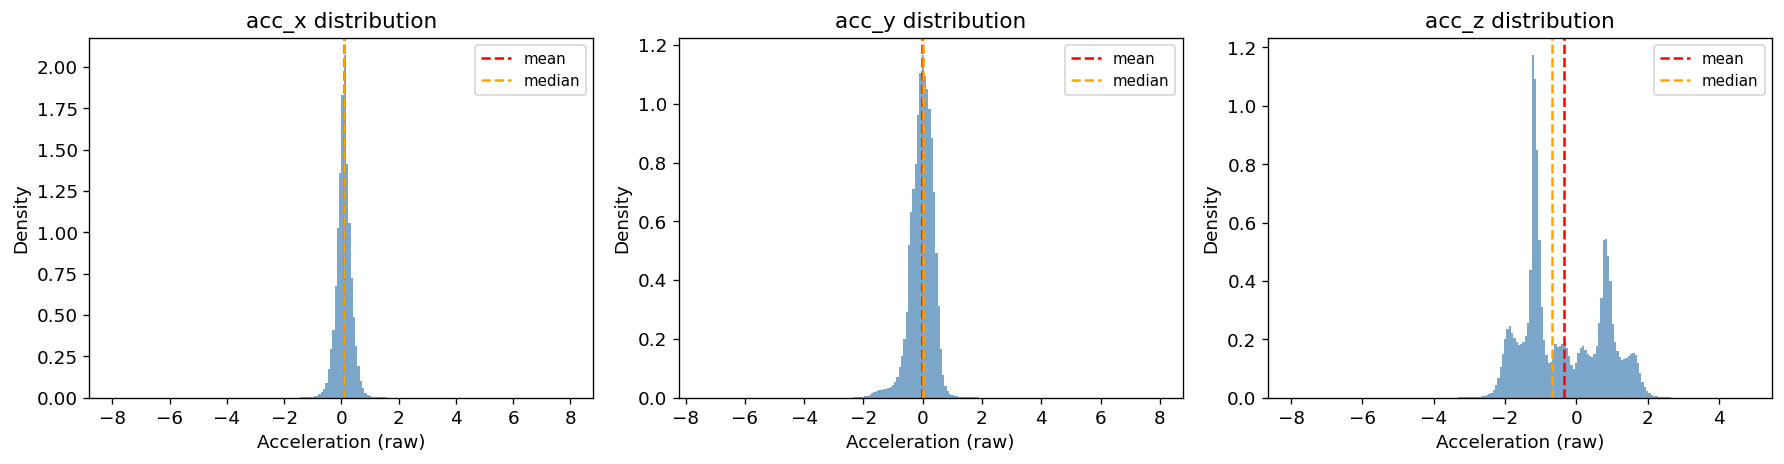

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, AXES):
    ax.hist(df_known[col].dropna(), bins=200, color='steelblue', alpha=0.7, density=True)
    ax.axvline(df_known[col].mean(), color='red', linestyle='--', label='mean')
    ax.axvline(df_known[col].median(), color='orange', linestyle='--', label='median')
    ax.set_title(f'{col} distribution')
    ax.set_xlabel('Acceleration (raw)')
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'global_distribution.png'), bbox_inches='tight')
plt.show()

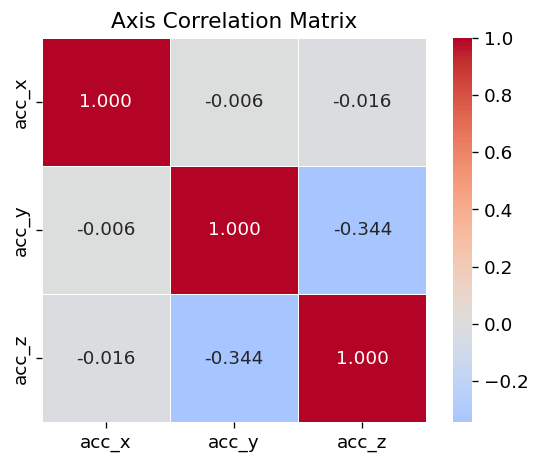

In [10]:
corr = df_known[AXES].corr()
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', center=0, ax=ax, square=True, linewidths=0.5)
ax.set_title('Axis Correlation Matrix')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'axis_correlation.png'), bbox_inches='tight')
plt.show()

## 6. Per-Class Statistics (Windowed npy)

In [11]:
rows = []
for label in labels_to_analyze:
    mask = y == label
    x_cls = X[mask]
    for ai, axis in enumerate(AXES):
        vals = x_cls[:, ai, :].ravel()
        rows.append({'label': label, 'behavior': LABEL_NAMES.get(label, str(label)), 'axis': axis,
                     'n_windows': int(mask.sum()), 'mean': vals.mean(), 'std': vals.std(),
                     'min': vals.min(), 'max': vals.max(),
                     'p25': np.percentile(vals, 25), 'p75': np.percentile(vals, 75),
                     'skew': stats.skew(vals), 'kurtosis': stats.kurtosis(vals)})

stat_df    = pd.DataFrame(rows)
pivot_stat = stat_df.pivot_table(index=['behavior','axis'],
    values=['n_windows','mean','std','min','max','p25','p75','skew','kurtosis'])
print('=== Per-class, per-axis statistics ===')
print(pivot_stat.round(3).to_string())

=== Per-class, per-axis statistics ===
                      kurtosis     max   mean     min  n_windows    p25    p75   skew    std
behavior       axis                                                                         
bathing        acc_x    20.117  29.338 -0.081 -26.823      753.0 -0.854  0.694  0.260  1.609
               acc_y     7.831  13.218  0.051 -11.915      753.0 -0.499  0.581  0.019  1.134
               acc_z     0.311   4.612  0.387  -6.778      753.0 -0.591  1.101 -0.812  0.932
body_shaking   acc_x    33.320   5.577 -0.729 -25.896        9.0 -1.536  0.668 -4.499  2.982
               acc_y    21.808  19.872 -0.288 -14.967        9.0 -0.994  0.291  1.850  2.431
               acc_z    25.094   2.735  1.004  -6.778        9.0  0.679  1.516 -3.985  0.964
flying_active  acc_x    17.376  28.271  0.038 -29.977    10348.0 -0.543  0.640 -0.435  1.041
               acc_y     6.761  19.992  0.070 -18.484    10348.0 -0.488  0.837 -0.989  1.141
               acc_z    -1.071 

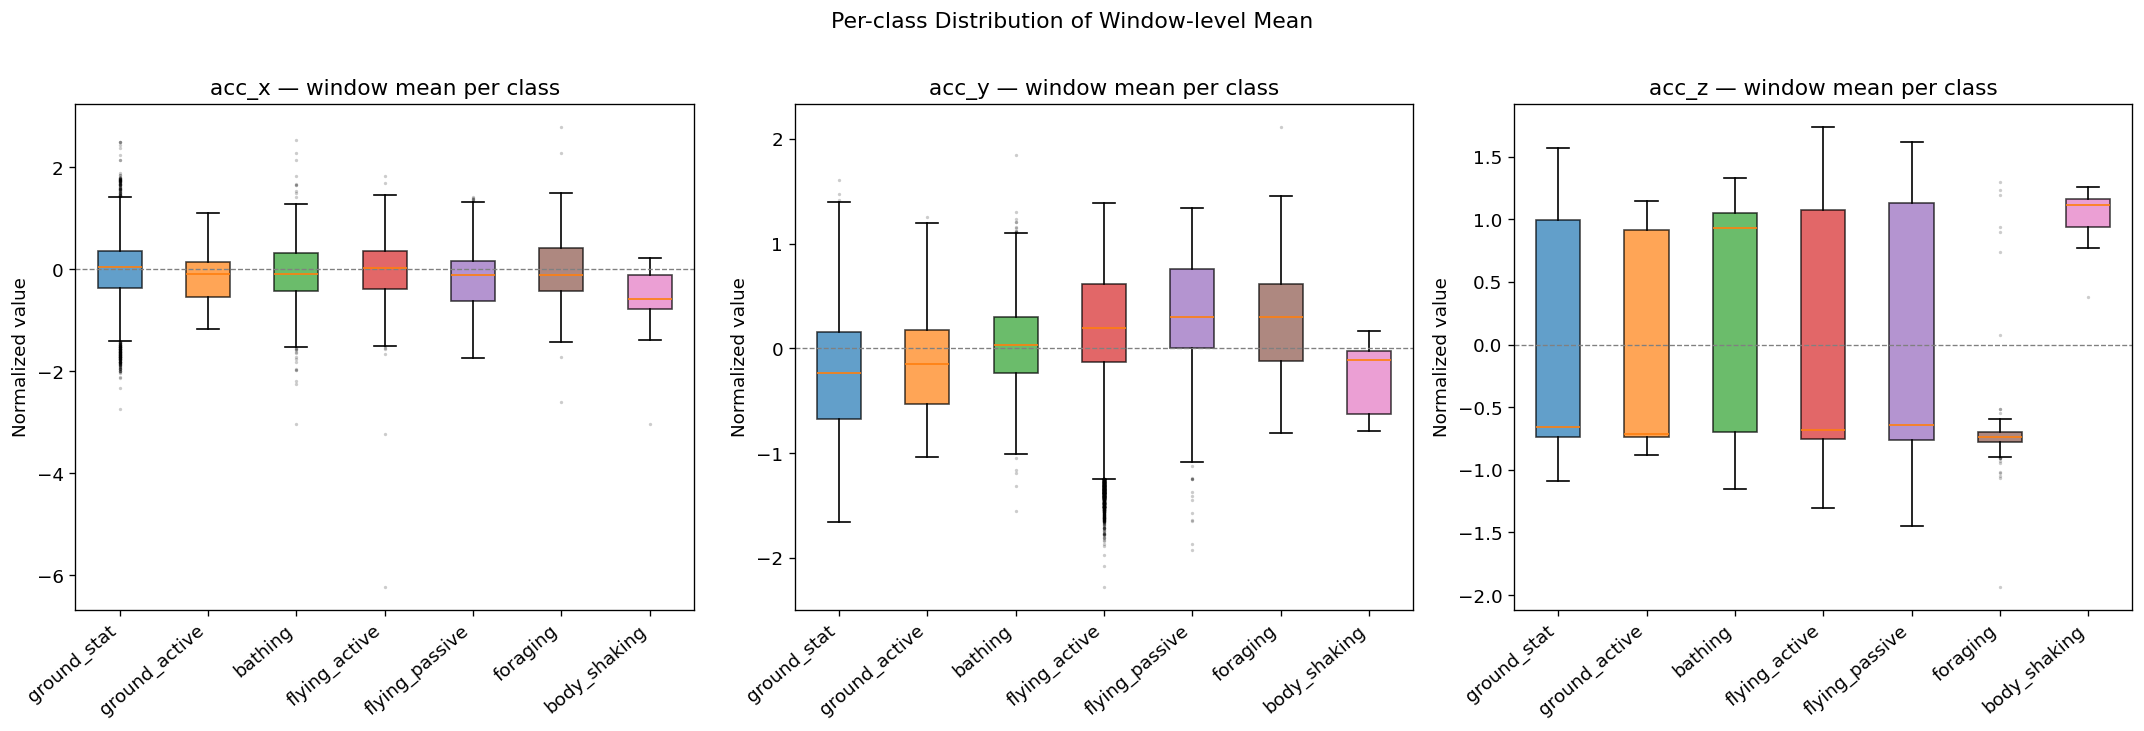

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ai, (ax, axis) in enumerate(zip(axes, AXES)):
    data_per_class = [X[y == l, ai, :].mean(axis=1) for l in labels_to_analyze]
    bp = ax.boxplot(data_per_class, labels=class_names, patch_artist=True,
                    flierprops=dict(marker='.', alpha=0.2, markersize=2))
    for patch, color in zip(bp['boxes'], COLORS):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    ax.set_title(f'{axis} — window mean per class')
    ax.set_ylabel('Normalized value')
    ax.set_xticklabels(class_names, rotation=40, ha='right')
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.suptitle('Per-class Distribution of Window-level Mean', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'per_class_boxplot.png'), bbox_inches='tight')
plt.show()

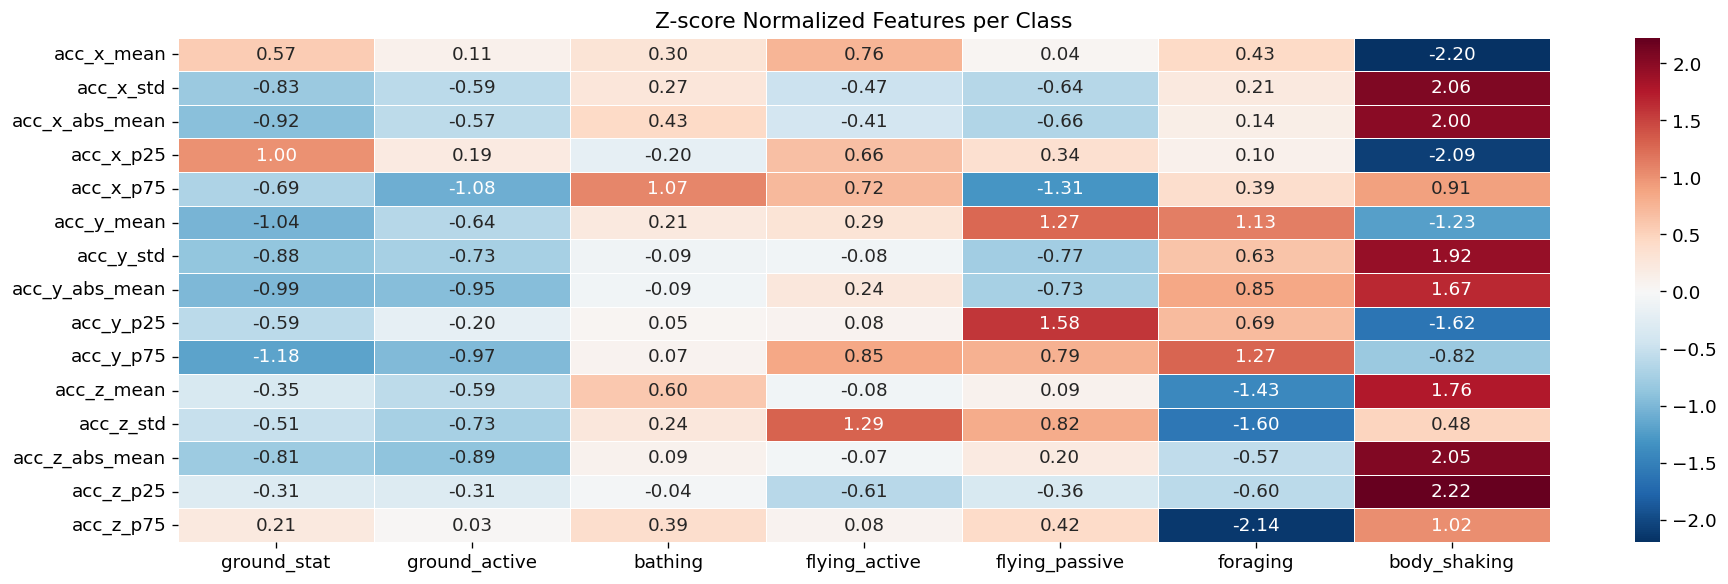

In [13]:
feat_matrix, feature_names = [], []
for label in labels_to_analyze:
    x_cls = X[y == label]
    row = []
    for ai in range(3):
        v = x_cls[:, ai, :]
        row += [v.mean(), v.std(), np.abs(v).mean(), np.percentile(v, 25), np.percentile(v, 75)]
    feat_matrix.append(row)
for axis in AXES:
    feature_names += [f'{axis}_mean', f'{axis}_std', f'{axis}_abs_mean', f'{axis}_p25', f'{axis}_p75']

feat_df   = pd.DataFrame(feat_matrix, index=class_names, columns=feature_names)
feat_norm = (feat_df - feat_df.mean()) / (feat_df.std() + 1e-8)
fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(feat_norm.T, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax, linewidths=0.3)
ax.set_title('Z-score Normalized Features per Class')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'class_feature_heatmap.png'), bbox_inches='tight')
plt.show()

## 7. Signal Magnitude & Energy

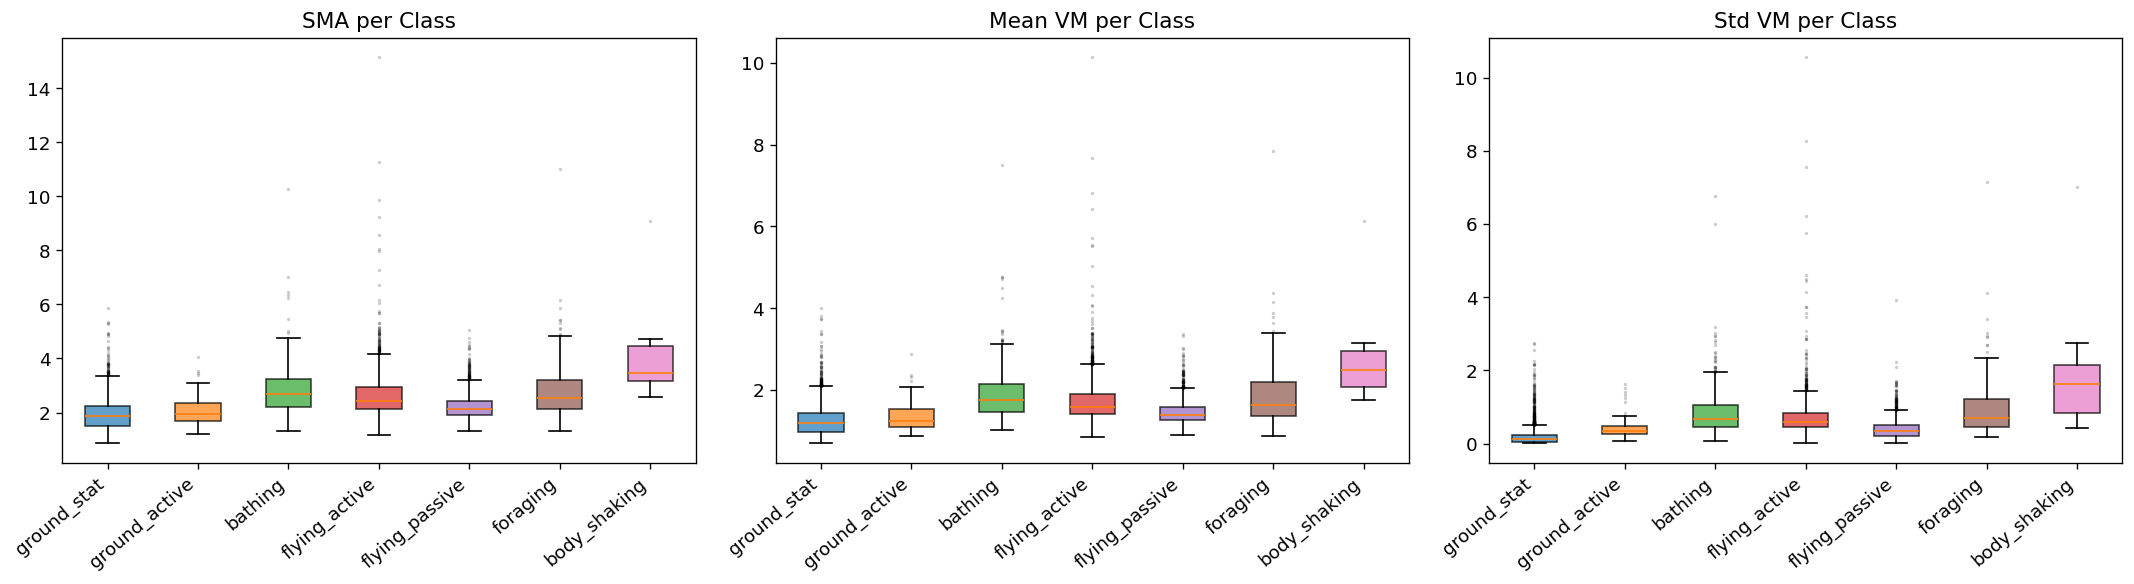

In [14]:
SMA     = np.abs(X).sum(axis=1).mean(axis=1)
VM_mean = np.sqrt((X**2).sum(axis=1)).mean(axis=1)
VM_std  = np.sqrt((X**2).sum(axis=1)).std(axis=1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, metric, title in zip(axes, [SMA, VM_mean, VM_std], ['SMA', 'Mean VM', 'Std VM']):
    data_cls = [metric[y == l] for l in labels_to_analyze]
    bp = ax.boxplot(data_cls, labels=class_names, patch_artist=True,
                    flierprops=dict(marker='.', alpha=0.2, markersize=2))
    for patch, color in zip(bp['boxes'], COLORS):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    ax.set_title(f'{title} per Class')
    ax.set_xticklabels(class_names, rotation=40, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'magnitude_energy.png'), bbox_inches='tight')
plt.show()

## 8. Frequency Domain Analysis

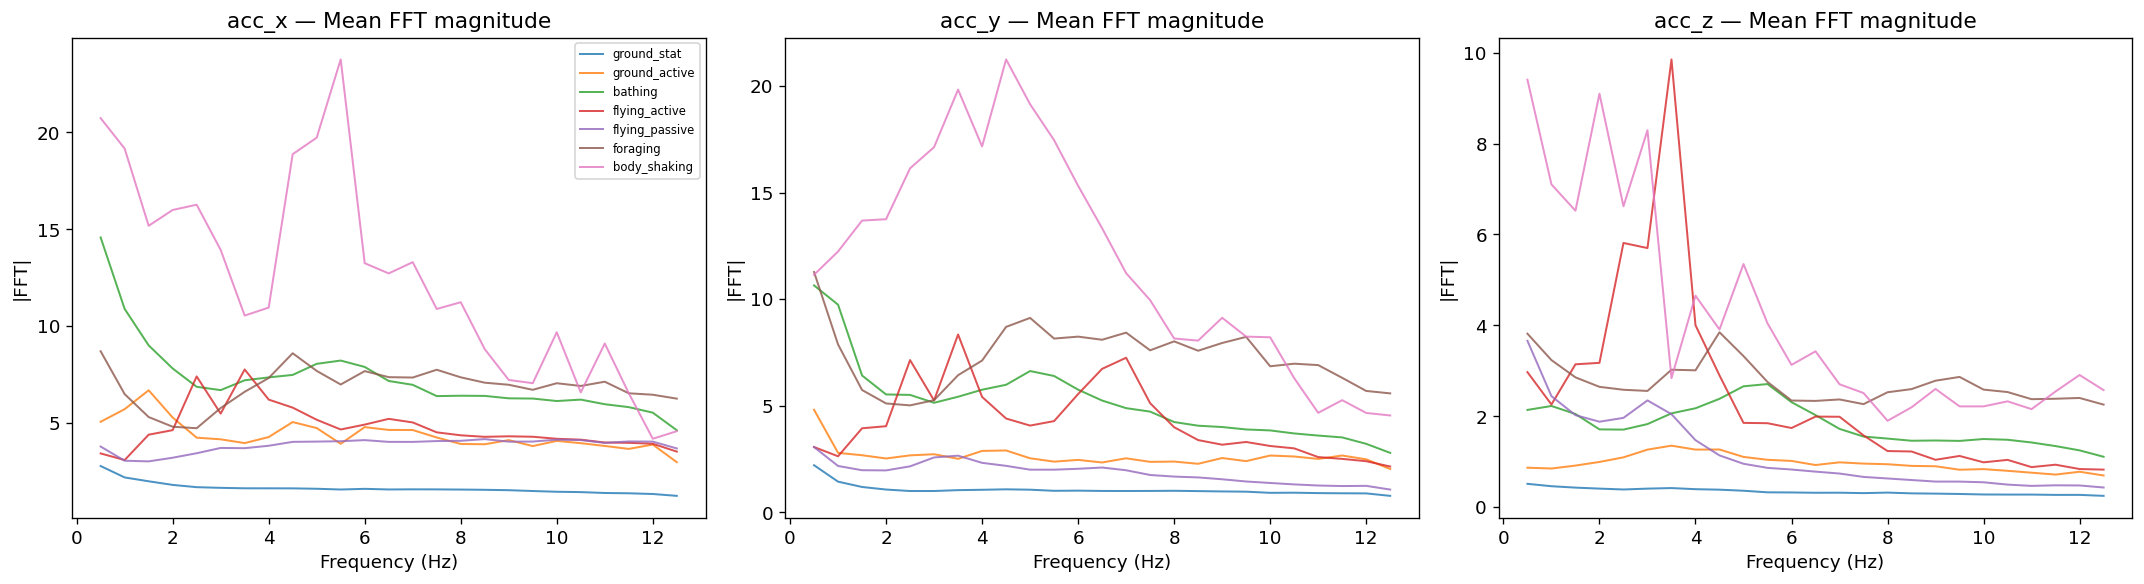

In [15]:
T     = X.shape[2]
freqs = np.fft.rfftfreq(T, d=1.0/SAMPLE_RATE)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ai, (ax, axis) in enumerate(zip(axes, AXES)):
    for li, label in enumerate(labels_to_analyze):
        x_cls   = X[y == label, ai, :]
        fft_mag = np.abs(np.fft.rfft(x_cls, axis=1)).mean(axis=0)
        ax.plot(freqs[1:], fft_mag[1:], label=LABEL_NAMES.get(label, str(label)),
                color=COLORS[li], alpha=0.8, linewidth=1.2)
    ax.set_title(f'{axis} — Mean FFT magnitude')
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('|FFT|')
    if ai == 0:
        ax.legend(fontsize=7, loc='upper right')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'psd_per_class.png'), bbox_inches='tight')
plt.show()

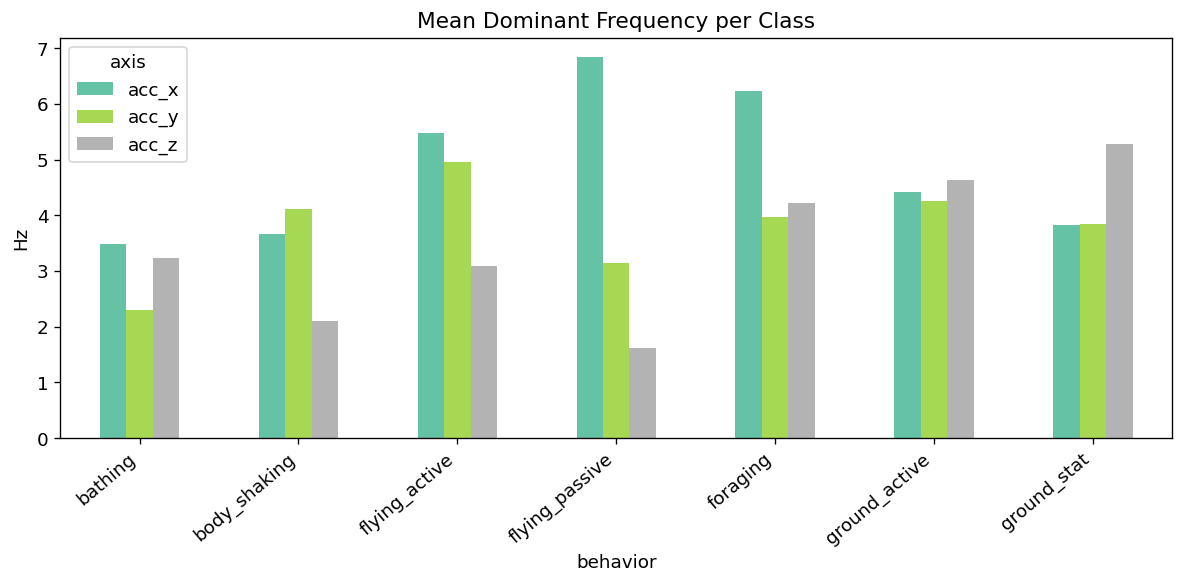

axis            acc_x  acc_y  acc_z
behavior                           
bathing         3.485  2.298  3.231
body_shaking    3.667  4.111  2.111
flying_active   5.488  4.963  3.099
flying_passive  6.851  3.141  1.612
foraging        6.233  3.979  4.215
ground_active   4.425  4.257  4.631
ground_stat     3.821  3.847  5.280


In [16]:
rows_dom = []
for label in labels_to_analyze:
    for ai, axis in enumerate(AXES):
        x_cls    = X[y == label, ai, :]
        fft_mag  = np.abs(np.fft.rfft(x_cls, axis=1))[:, 1:]
        dom_freq = freqs[1:][fft_mag.argmax(axis=1)]
        rows_dom.append({'behavior': LABEL_NAMES.get(label, str(label)), 'axis': axis,
                         'mean_dom_freq': dom_freq.mean(), 'std': dom_freq.std()})

pivot_dom = pd.DataFrame(rows_dom).pivot(index='behavior', columns='axis', values='mean_dom_freq')
fig, ax = plt.subplots(figsize=(10, 5))
pivot_dom.plot(kind='bar', ax=ax, colormap='Set2')
ax.set_title('Mean Dominant Frequency per Class')
ax.set_ylabel('Hz')
ax.set_xticklabels(pivot_dom.index, rotation=40, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'dominant_freq.png'), bbox_inches='tight')
plt.show()
print(pivot_dom.round(3).to_string())

## 9. Average Window Shape per Class

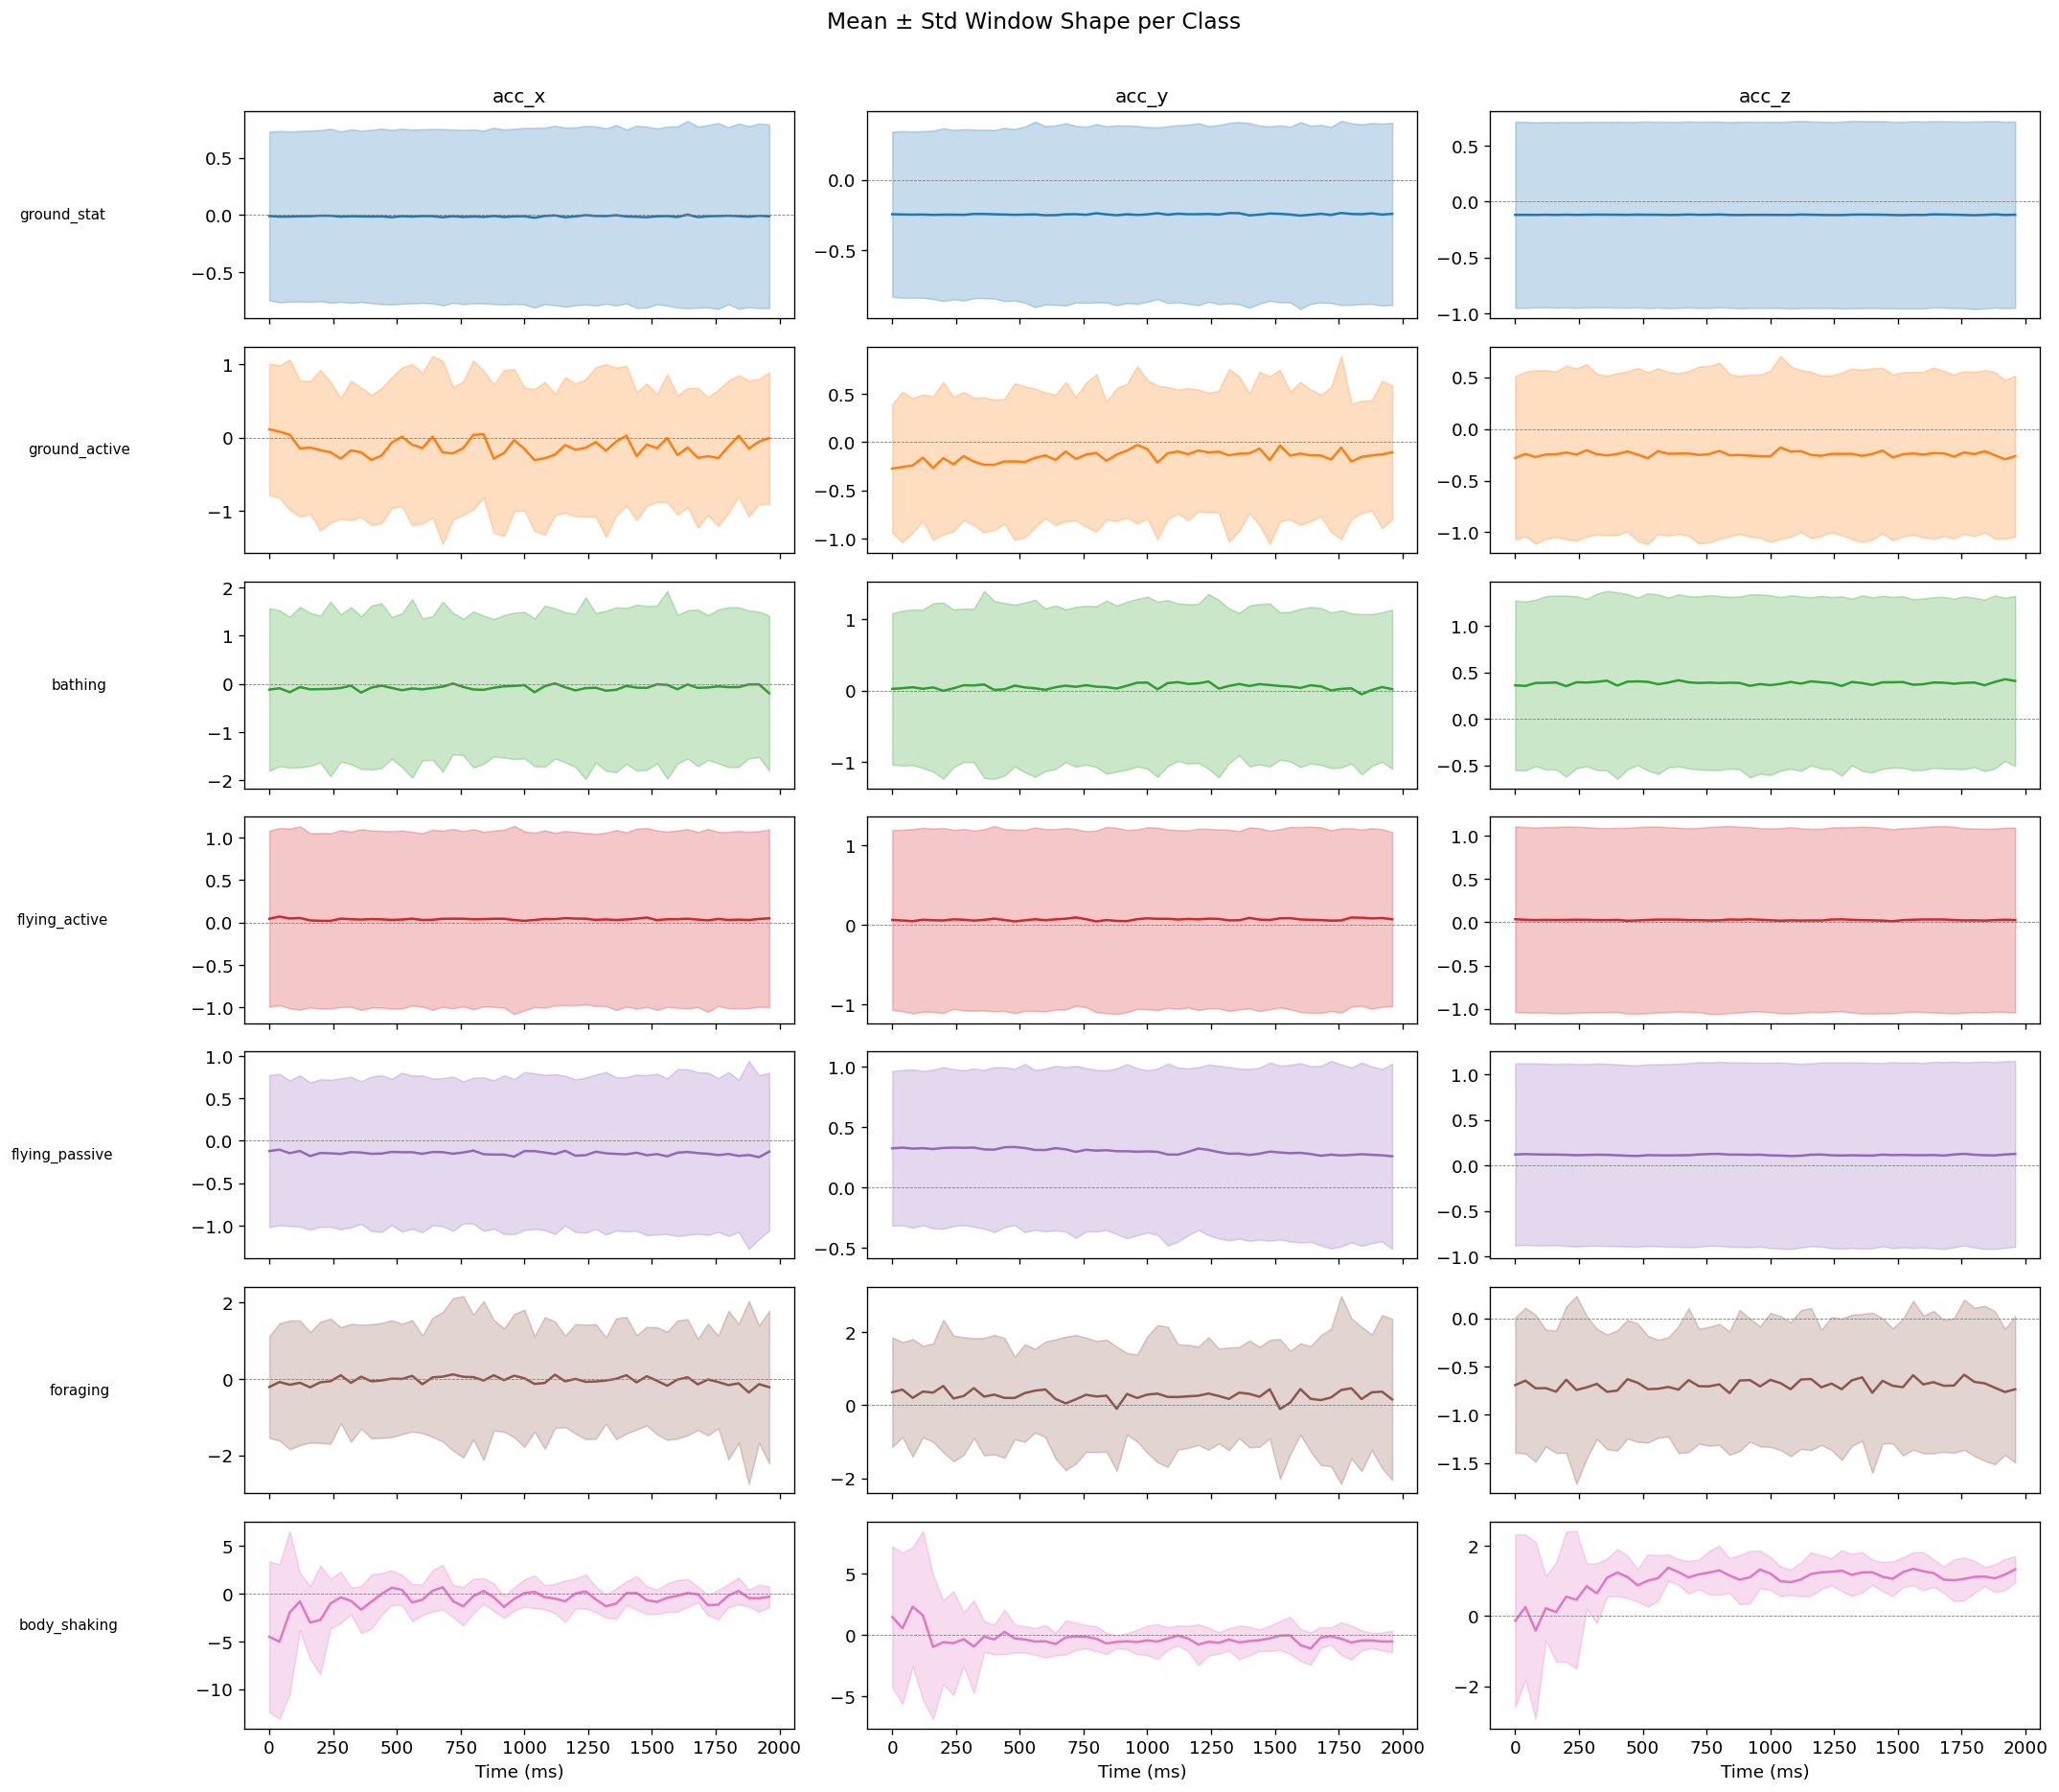

In [17]:
n_cls = len(labels_to_analyze)
fig, axes = plt.subplots(n_cls, 3, figsize=(18, 2.2 * n_cls), sharex=True)
t = np.arange(T) / SAMPLE_RATE * 1000
if n_cls == 1:
    axes = axes[np.newaxis, :]

for row, label in enumerate(labels_to_analyze):
    x_cls = X[y == label]
    for ai, axis in enumerate(AXES):
        ax = axes[row, ai]
        mu = x_cls[:, ai, :].mean(axis=0)
        sd = x_cls[:, ai, :].std(axis=0)
        ax.plot(t, mu, color=COLORS[row], linewidth=1.5)
        ax.fill_between(t, mu - sd, mu + sd, alpha=0.25, color=COLORS[row])
        ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
        if row == 0:
            ax.set_title(axis, fontsize=12)
        if ai == 0:
            ax.set_ylabel(LABEL_NAMES.get(label, str(label)), fontsize=9,
                          rotation=0, labelpad=80, va='center')
        if row == n_cls - 1:
            ax.set_xlabel('Time (ms)')

plt.suptitle('Mean ± Std Window Shape per Class', y=1.01, fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'avg_window_per_class.png'), bbox_inches='tight')
plt.show()

## 10. Between-Class Separability

=== Kruskal-Wallis H-test ===
  acc_x: H=4393.65, p=0.00e+00  → SIGNIFICANT
  acc_y: H=63998.85, p=0.00e+00  → SIGNIFICANT
  acc_z: H=12710.36, p=0.00e+00  → SIGNIFICANT


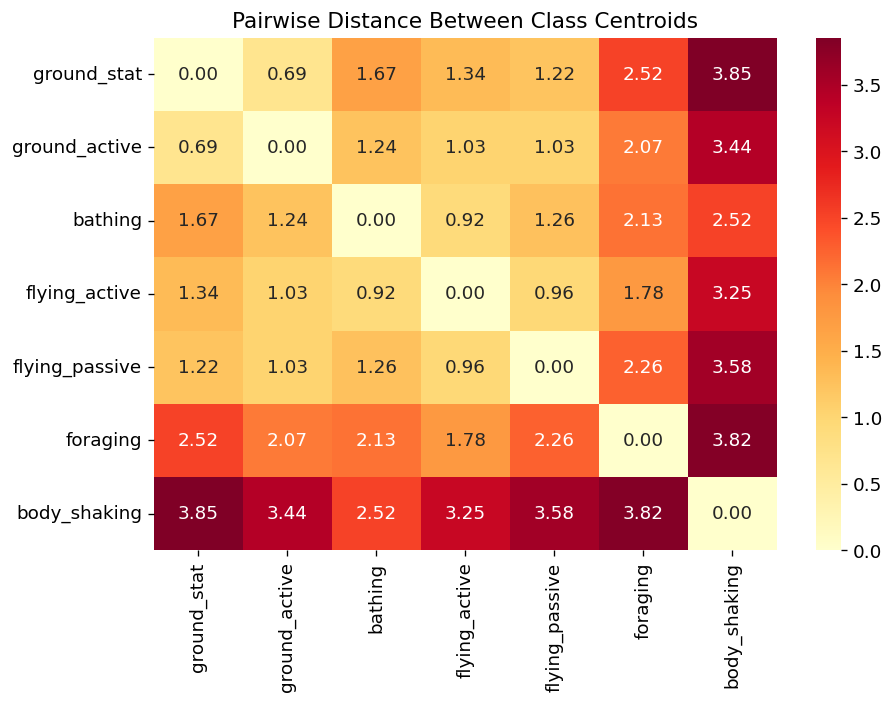

In [18]:
print('=== Kruskal-Wallis H-test ===')
for ai, axis in enumerate(AXES):
    groups = [X[y == l, ai, :].ravel() for l in labels_to_analyze]
    h, pv  = kruskal(*groups)
    print(f'  {axis}: H={h:.2f}, p={pv:.2e}  → {"SIGNIFICANT" if pv < 0.05 else "not significant"}')

def class_centroid(x_cls):
    feats = []
    for ai in range(3):
        v = x_cls[:, ai, :]
        feats += [v.mean(axis=1).mean(), v.std(axis=1).mean(),
                  np.percentile(v,25), np.percentile(v,75), np.abs(v).mean()]
    return np.array(feats)

centroids = np.array([class_centroid(X[y == l]) for l in labels_to_analyze])
dist_mat  = pairwise_distances(centroids)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(dist_mat, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_title('Pairwise Distance Between Class Centroids')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'pairwise_class_distance.png'), bbox_inches='tight')
plt.show()

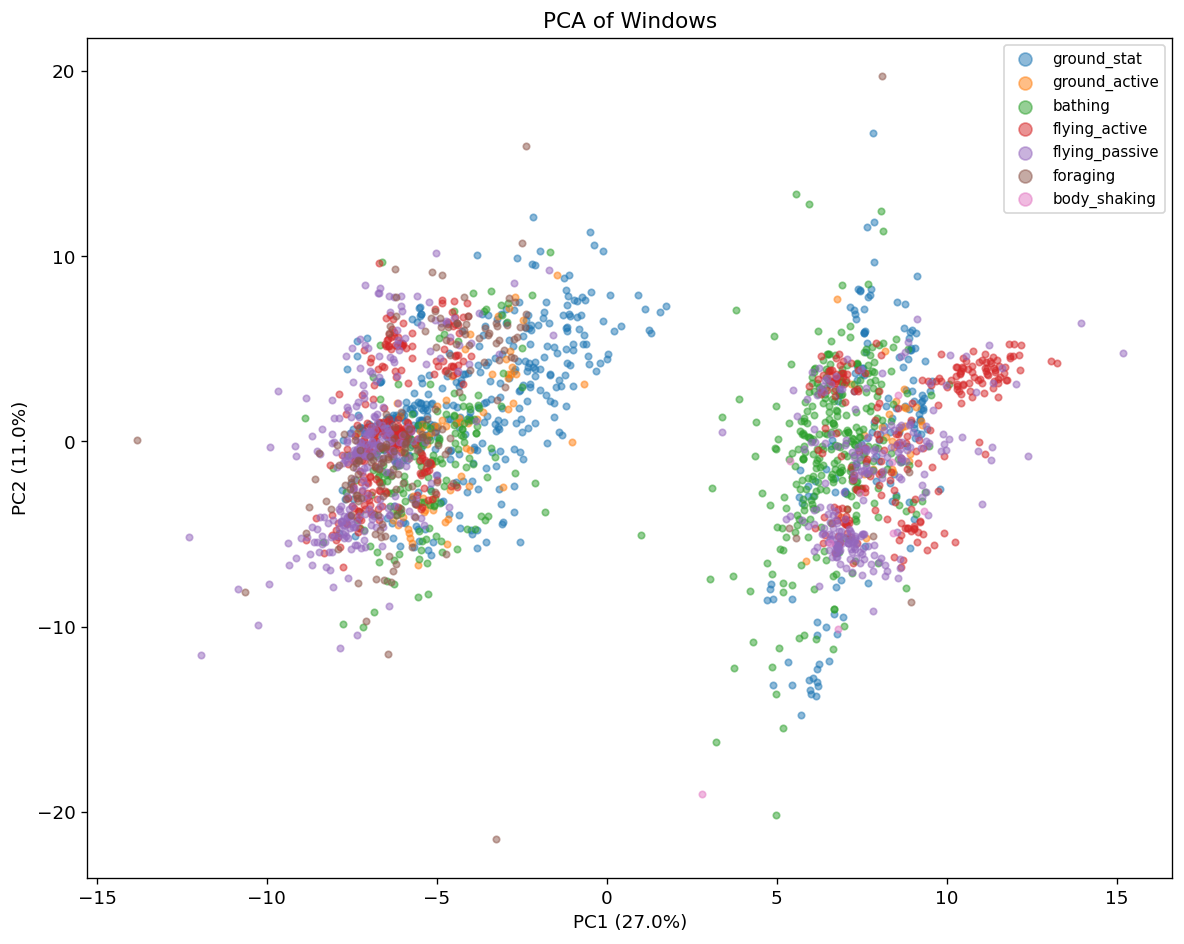

In [19]:
N_PER_CLASS = 500
idx_all = []
for label in labels_to_analyze:
    idx_l  = np.where(y == label)[0]
    n_take = min(N_PER_CLASS, len(idx_l))
    idx_all.append(np.random.choice(idx_l, n_take, replace=False))
idx_all = np.concatenate(idx_all)
X_flat  = X[idx_all].reshape(len(idx_all), -1)
y_sub   = y[idx_all]

pca   = PCA(n_components=2)
X_pca = pca.fit_transform(X_flat)
fig, ax = plt.subplots(figsize=(10, 8))
for li, label in enumerate(labels_to_analyze):
    mask = y_sub == label
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=[COLORS[li]],
               label=LABEL_NAMES.get(label, str(label)), alpha=0.5, s=15)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('PCA of Windows')
ax.legend(markerscale=2, fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'pca_visualization.png'), bbox_inches='tight')
plt.show()

## 11. Axis Cross-Correlation per Class

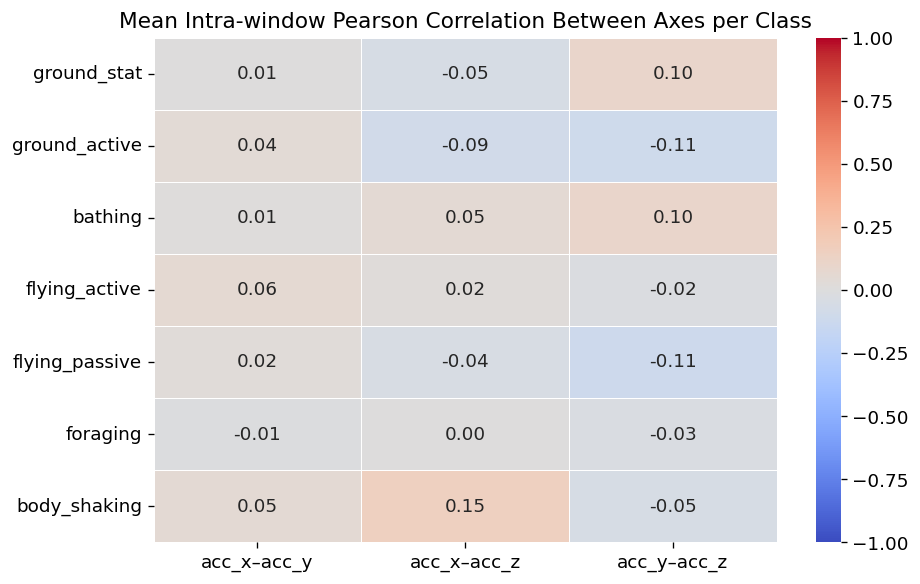

In [20]:
axis_pairs = [('acc_x','acc_y',0,1), ('acc_x','acc_z',0,2), ('acc_y','acc_z',1,2)]
corr_data  = {f'{a}–{b}': [] for a,b,_,__ in axis_pairs}
for label in labels_to_analyze:
    x_cls = X[y == label]
    for a_name, b_name, ai, bi in axis_pairs:
        r_vals = [np.corrcoef(x_cls[n, ai], x_cls[n, bi])[0, 1] for n in range(len(x_cls))]
        corr_data[f'{a_name}–{b_name}'].append(np.nanmean(r_vals))

corr_df = pd.DataFrame(corr_data, index=class_names)
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(corr_df, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax, linewidths=0.5, vmin=-1, vmax=1)
ax.set_title('Mean Intra-window Pearson Correlation Between Axes per Class')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'axis_xcorr_per_class.png'), bbox_inches='tight')
plt.show()

## 12. Window Quality & Label Consistency

In [21]:
y_all    = Y.astype(int)
all_same = (y_all == y_all[:, [0]]).all(axis=1)
print(f'Windows with consistent labels : {all_same.sum():,} / {len(all_same):,} ({all_same.mean()*100:.1f}%)')
print(f'Windows with mixed labels      : {(~all_same).sum():,} ({(~all_same).mean()*100:.1f}%)')
print(f'Window: {T} timesteps = {T/SAMPLE_RATE*1000:.0f} ms at {SAMPLE_RATE} Hz')
print(f'Total windows: {len(X):,}')
for ai, axis in enumerate(AXES):
    v = X[:, ai, :]
    print(f'{axis}: min={v.min():.4f}  max={v.max():.4f}  mean={v.mean():.6f}  std={v.std():.6f}')

Windows with consistent labels : 16,755 / 18,393 (91.1%)
Windows with mixed labels      : 1,638 (8.9%)
Window: 50 timesteps = 2000 ms at 25 Hz
Total windows: 18,393
acc_x: min=-29.9769  max=29.3385  mean=0.000001  std=1.000022
acc_y: min=-18.4844  max=20.0010  mean=0.000022  std=1.000015
acc_z: min=-6.7779  max=4.6121  mean=-0.000050  std=0.999994


## 13. Raw label mapping across years

Summarize which raw string labels contribute to each canonical class per year.

In [22]:
cross = df_known.groupby(['year', 'label', 'canon_id']).size().reset_index()
cross.columns = ['year', 'raw_label', 'canon_id', 'count']
cross['behavior'] = cross['canon_id'].map(LABEL_NAMES)
print(cross.sort_values(['canon_id', 'year']).to_string(index=False))

 year            raw_label  canon_id  count       behavior
 2018    ground_stationary         0  56807    ground_stat
 2018             preening         0   1300    ground_stat
 2018           stationary         0  23827    ground_stat
 2019    ground_stationary         0 118451    ground_stat
 2019           stationary         0  34601    ground_stat
 2022    ground_stationary         0  16505    ground_stat
 2022             preening         0    340    ground_stat
 2022           stationary         0  13713    ground_stat
 2018        ground_active         1   1402  ground_active
 2019        ground_active         1   3772  ground_active
 2018              bathing         2   9609        bathing
 2018         bathing_poss         2   3732        bathing
 2019              bathing         2  10230        bathing
 2019         bathing_poss         2   2614        bathing
 2022              bathing         2  11264        bathing
 2018        flying_active         3 126764  flying_acti

## 14. Summary Table

In [23]:
summary_rows = []
for label, pi in zip(labels_to_analyze, p):
    mask    = y == label
    x_cls   = X[mask]
    sma_val = np.abs(x_cls).sum(axis=1).mean(axis=1).mean()
    vm_val  = np.sqrt((x_cls**2).sum(axis=1)).mean(axis=1).mean()
    row = {'label': label, 'behavior': LABEL_NAMES.get(label, str(label)),
           'n_windows': int(mask.sum()), 'prop_%': round(pi * 100, 2),
           'inv_freq_weight': round((1/pi) / sum(1/q for q in p), 4),
           'SMA_mean': round(float(sma_val), 4), 'VM_mean': round(float(vm_val), 4)}
    for ai, axis in enumerate(AXES):
        v = x_cls[:, ai, :]
        row[f'{axis}_mean'] = round(float(v.mean()), 4)
        row[f'{axis}_std']  = round(float(v.std()),  4)
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index('label')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 220)
print('=== Summary for Model Training ===')
print(summary_df.to_string())

=== Summary for Model Training ===
             behavior  n_windows  prop_%  inv_freq_weight  SMA_mean  VM_mean  acc_x_mean  acc_x_std  acc_y_mean  acc_y_std  acc_z_mean  acc_z_std
label                                                                                                                                            
0         ground_stat       5307   28.85           0.0015    1.9075   1.2454     -0.0107     0.7711     -0.2440     0.6237     -0.1183     0.8339
1       ground_active        107    0.58           0.0726    2.0469   1.3367     -0.1302     0.9490     -0.1499     0.7187     -0.2436     0.8053
2             bathing        753    4.09           0.0103    2.8195   1.8815     -0.0805     1.6086      0.0512     1.1338      0.3865     0.9325
3       flying_active      10348   56.26           0.0008    2.5542   1.6765      0.0384     1.0412      0.0698     1.1410      0.0260     1.0700
4      flying_passive       1706    9.28           0.0046    2.2183   1.4624     -0.1480 